# Sustainability Aware Asset Management
## Group BB — Emerging Markets | Scope 1

---

**Matthieu Pagot, Aymen Laraoui, Cédric Nim, Rijad Talovic**

---
## Libraries & Configuration

In [103]:
# Libraries import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

In [104]:
#Data path
data_path = 'Data_2026/' #changer si nécessaire

#Group Parameters
region = "EM"

#Configuration
low_prices_threshold = 0.5
stale_threshold = 0.5 # Proportion max de rendements nuls tolérée (50%)

---
# Part I — Standard Portfolio Allocation

## 1. Data Handling

### 1.1 Data Loading

In [105]:
#Static file Loading and filtering to emerging markets

static_file = pd.read_excel(f'{data_path}Static_2025.xlsx')
emerging_market_data = static_file[static_file['Region'] == region]
#print(emerging_market_data)

#Function to load Data files
def load_data(file_name):
  data = pd.read_excel(f'{data_path}{file_name}')
  data = data.dropna(subset=['ISIN']) # drop error rows
  data = data[data['ISIN'].isin(emerging_market_data['ISIN'])] #Keep emerging markets only
  data = data.set_index('ISIN') #Make ISIN the index
  data = data.drop(columns=['NAME']) #Drop the name column
  data = data.loc[:, data.columns.notna()] #drop columns with NaN
  data = data.apply(pd.to_numeric, errors='coerce') #Tries to convert every cell to a number and if it can't turn it into NaN

  return data

In [106]:
#Load all the data files

#Return Index
ri_monthly = load_data('DS_RI_T_USD_M_2025.xlsx') # monthly total return index (prices)
ri_yearly  = load_data('DS_RI_T_USD_Y_2025.xlsx') # yearly total return index

#Market Capitalization
mv_monthly = load_data('DS_MV_T_USD_M_2025.xlsx') # monthly market capitalization
mv_yearly  = load_data('DS_MV_T_USD_Y_2025.xlsx') # yearly market capitalization

#Co2 Scope 1 Emissions
co2_scope1 = load_data('DS_CO2_SCOPE_1_Y_2025.xlsx') # yearly CO2 scope 1 emissions (tonnes)
co2_scope1 = co2_scope1.ffill(axis=1) # forward-fill les années manquantes (consigne PDF section 1)

#Revenues
revenues   = load_data('DS_REV_Y_2025.xlsx') # yearly revenues (thousands USD)
revenues   = revenues.ffill(axis=1) # forward-fill les années manquantes (consigne PDF section 1)

#petit aperçu de la data
print(static_file.columns.tolist())
print(emerging_market_data[['NAME', 'Country', 'Region']].head())

['ISIN', 'NAME', 'Country', 'Region']
                                   NAME Country Region
1                                 ALUAR      AR     EM
2                  BANCO BBVA ARGENTINA      AR     EM
3    TERNIUM ARGENTINA SOCIEDAD ANONIMA      AR     EM
117              CHINA YURUN FOOD GROUP      CN     EM
144                            AMBEV ON      BR     EM


In [107]:
#Load the Risk Free Rate

rf_raw = pd.read_excel(f'{data_path}Risk_Free_Rate_2025.xlsx')
rf_raw.columns = ['Date', 'Risk Free Rate']
rf_raw['Date'] = pd.to_datetime(rf_raw['Date'].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
rf = rf_raw.set_index('Date')['Risk Free Rate'] / 100

### 1.2 Data Cleaning

In [108]:
#Remove the firms with no data

# Prix bas : Remplacer les valeurs strictement inférieures au seuil par NaN
ri_monthly[ri_monthly < low_prices_threshold] = np.nan

# Boucher les trous : Combler les valeurs manquantes isolées avec le prix précédent
ri_monthly = ri_monthly.ffill(limit=1, axis=1)

In [109]:
# Calculer les rendements mensuels à partir des prix
prices = ri_monthly.copy()

# Calculer les rendements simples (pct_change sur les colonnes = dans le temps)
returns = prices.pct_change(axis=1)

# Gérer les faillites (delistings) : forcer le rendement à -100%, le masque repère : mois t-1 avait un prix ET mois t est vide
cols = prices.columns
for i in range(1, len(cols)):
    prev_col = cols[i - 1]
    curr_col = cols[i]
    mask = prices[curr_col].isna() & prices[prev_col].notna()
    returns.loc[mask, curr_col] = -1.0

# Nettoyer les infinis (divisions par zéro)
returns = returns.replace([np.inf, -np.inf], np.nan)

print(f"Shape des returns : {returns.shape}")
print(f"Valeurs infinies restantes : {np.isinf(returns.values).sum()}")

Shape des returns : (702, 314)
Valeurs infinies restantes : 0


In [110]:
# ── Aperçu des objets disponibles ────────────────────────────────────────────
objects = {
    "prices": prices,
    "returns": returns,
    "ri_yearly": ri_yearly,
    "mv_monthly": mv_monthly,
    "mv_yearly": mv_yearly,
    "co2_scope1": co2_scope1,
    "revenues": revenues,
}

for name, df in objects.items():
    print(f"{name} -> {df.shape} | {str(df.columns[0])[:10]} -> {str(df.columns[-1])[:10]}")

prices -> (702, 314) | 1999-12-31 -> 2026-01-30
returns -> (702, 314) | 1999-12-31 -> 2026-01-30
ri_yearly -> (702, 27) | 1999 -> 2025
mv_monthly -> (702, 314) | 1999-12-31 -> 2026-01-30
mv_yearly -> (702, 27) | 1999 -> 2025
co2_scope1 -> (702, 27) | 1999 -> 2025
revenues -> (702, 27) | 1999 -> 2025


---
## 2. Minimum-Variance Portfolio Allocation

### 2.1 Investment Set

Pour chaque année d'investissement Y (de 2014 à 2024), on constitue l'univers investissable à partir des données disponibles fin Y-1. Les variables construites sont :

| Variable | Description |
|---|---|
| `emerging_market_data` | Entreprises EM (filtre région) |
| `eligible_isins` | ISINs EM ayant déclaré leurs émissions CO2 fin Y-1 |
| `filtered_isins` | Survivants aux 3 filtres financiers (historique, stale, dernier prix) |
| `filtered_carbon_isin_dict` | Dictionnaire final `{année: [ISINs éligibles]}` pour l'optimisation |

In [111]:
# Pour avoir le set d'investissment possible par année, on doit appliquer les filtres suivants :

filtered_carbon_isin_dict = {}

for year in range(2014, 2026): # 2014 à 2025 inclus = 12 ans = 144 mois (T=144 requis par le PDF)

    # Fenêtre de temps dynamique de 10 ans
    end_date = returns.columns[returns.columns.astype(str).str.contains(str(year-1))].max()
    end_idx = returns.columns.get_loc(end_date)
    start_idx = end_idx - 119
    window_cols = returns.columns[start_idx:end_idx+1]

    # ÉTAPE 2 : FILTRE CARBONE — ISINs ayant déclaré des émissions CO2 pour Y-1
    prev_year = year - 1
    matching_cols = [col for col in co2_scope1.columns
                     if str(col) == str(prev_year) or (hasattr(col, 'year') and col.year == prev_year)]
    eligible_isins = co2_scope1[matching_cols[0]].dropna().index.tolist() if matching_cols else []

    filtered_isins = []

    # ÉTAPE 3 : FILTRES FINANCIERS
    for isin in eligible_isins:
        if isin not in returns.index:
            continue
        returns_series = returns.loc[isin, window_cols]

        # FILTRE A : min 36 mois valides sur 120
        has_enough_data = returns_series.notna().sum() >= 36

        # FILTRE B : exclure si proportion de rendements nuls > stale_threshold
        has_stale_prices = (returns_series == 0.0).sum() / 120 > stale_threshold

        # FILTRE C : dernier PRIX valide (et non dernier rendement — cf. consigne PDF)
        last_price_valid = (isin in prices.index) and pd.notna(prices.loc[isin, end_date])

        if has_enough_data and not has_stale_prices and last_price_valid:
            filtered_isins.append(isin)

    filtered_carbon_isin_dict[year] = filtered_isins

    print(f"Annee {year} (Fenetre du {window_cols[0].date()} au {window_cols[-1].date()}) :")
    print(f"  -> {len(filtered_isins)} actions conservees sur {len(eligible_isins)} eligibles au depart.")

Annee 2014 (Fenetre du 2004-01-30 au 2013-12-31) :
  -> 254 actions conservees sur 286 eligibles au depart.
Annee 2015 (Fenetre du 2005-01-31 au 2014-12-31) :
  -> 280 actions conservees sur 313 eligibles au depart.
Annee 2016 (Fenetre du 2006-01-31 au 2015-12-31) :
  -> 312 actions conservees sur 349 eligibles au depart.
Annee 2017 (Fenetre du 2007-01-31 au 2016-12-30) :
  -> 346 actions conservees sur 383 eligibles au depart.
Annee 2018 (Fenetre du 2008-01-31 au 2017-12-29) :
  -> 389 actions conservees sur 428 eligibles au depart.
Annee 2019 (Fenetre du 2009-01-30 au 2018-12-31) :
  -> 425 actions conservees sur 467 eligibles au depart.
Annee 2020 (Fenetre du 2010-01-29 au 2019-12-31) :
  -> 472 actions conservees sur 521 eligibles au depart.
Annee 2021 (Fenetre du 2011-01-31 au 2020-12-31) :
  -> 512 actions conservees sur 565 eligibles au depart.
Annee 2022 (Fenetre du 2012-01-31 au 2021-12-31) :
  -> 547 actions conservees sur 603 eligibles au depart.
Annee 2023 (Fenetre du 2013-

In [112]:
covariance_matrices = {}  # dictionnaire qui va stocker une matrice par année

for year in range(2014, 2026):  # on boucle sur chaque année d'investissement

    # On cherche la dernière colonne (= dernier mois) de l'année précédente (ex: déc 2013 pour year=2014)
    end_date = returns.columns[returns.columns.astype(str).str.contains(str(year - 1))].max()
    # On récupère la position (numéro de colonne) de cette date dans le DataFrame
    end_idx = returns.columns.get_loc(end_date)

    # On prend les 120 colonnes qui précèdent : c'est notre fenêtre de 10 ans (120 mois)
    window_cols = returns.columns[end_idx - 119 : end_idx + 1]

    isins = filtered_carbon_isin_dict[year]  # liste des ISINs éligibles pour cette année
    N     = len(isins)                        # nombre d'actifs éligibles

    # On extrait les rendements de ces N actifs sur la fenêtre de 120 mois → tableau numpy (N × 120)
    ret = returns.loc[isins, window_cols].values

    # ── Étape 1 : pour chaque actif, calculer sa moyenne et sa variance ──────
    means     = np.zeros(N)  # tableau de N zéros, un par actif
    variances = np.zeros(N)  # idem pour les variances

    for i in range(N):  # on parcourt chaque actif un par un
        valid = ret[i][~np.isnan(ret[i])]  # on garde uniquement les mois où le rendement n'est pas NaN
        if len(valid) >= 2:                # il faut au moins 2 valeurs pour calculer une variance
            means[i]     = np.mean(valid)       # moyenne sur l'historique valide
            variances[i] = np.var(valid, ddof=1) # variance (ddof=1 = diviseur N-1, estimateur non biaisé)

    # ── Étape 2 : initialiser la matrice N×N avec les variances sur la diagonale ──
    sigma = np.diag(variances)  # crée une matrice carrée : variances sur la diagonale, 0 partout ailleurs

    # ── Étape 3 : remplir les covariances entre chaque paire d'actifs ────────
    for i in range(N):
        for j in range(i + 1, N):  # on part de i+1 pour ne faire chaque paire qu'une seule fois

            if variances[i] == 0 or variances[j] == 0:  # si un actif n'a pas de variation → on skip
                continue

            # On garde uniquement les mois où les DEUX actifs ont un rendement valide en même temps
            both_valid = ~np.isnan(ret[i]) & ~np.isnan(ret[j])
            r_i = ret[i][both_valid]  # rendements de l'actif i sur les mois communs
            r_j = ret[j][both_valid]  # rendements de l'actif j sur les mois communs

            if len(r_i) < 2:  # pas assez de mois en commun → on skip
                continue

            # Calcul de la corrélation avec les moyennes GLOBALES (formule exacte du Cours 5)
            num   = np.sum((r_i - means[i]) * (r_j - means[j]))                          # numérateur
            denom = np.sqrt(np.sum((r_i - means[i])**2)) * np.sqrt(np.sum((r_j - means[j])**2))  # dénominateur

            if denom == 0:  # si un des actifs a toujours le même rendement → corrélation indéfinie
                continue

            cov = (num / denom) * np.sqrt(variances[i]) * np.sqrt(variances[j])  # Cov = rho * std_i * std_j

            sigma[i, j] = cov  # on remplit la case (i,j)
            sigma[j, i] = cov  # et la case (j,i) — la matrice est symétrique

    covariance_matrices[year] = sigma  # on sauvegarde la matrice de cette année
    print(f"Annee {year} : matrice {N}x{N} calculee")

Annee 2014 : matrice 254x254 calculee
Annee 2015 : matrice 280x280 calculee
Annee 2016 : matrice 312x312 calculee
Annee 2017 : matrice 346x346 calculee
Annee 2018 : matrice 389x389 calculee
Annee 2019 : matrice 425x425 calculee
Annee 2020 : matrice 472x472 calculee
Annee 2021 : matrice 512x512 calculee
Annee 2022 : matrice 547x547 calculee
Annee 2023 : matrice 573x573 calculee
Annee 2024 : matrice 584x584 calculee
Annee 2025 : matrice 570x570 calculee


### 2.2 Minimum-Variance Portfolio

In [113]:
# ─────────────────────────────────────────────────────────────────────────────
# PARAMÈTRE DE SHRINKAGE (fixé en dehors de la boucle)
# ─────────────────────────────────────────────────────────────────────────────
# Selon le paradoxe de Stein, l'estimateur empirique de la matrice de
# covariance est non biaisé mais très bruité lorsque N est grand par rapport
# à T=120. On "rétrécit" (shrink) cette matrice vers une cible diagonale
# très structurée (zéro corrélation supposée) afin de réduire l'erreur
# d'estimation et d'éviter que l'optimiseur de Markowitz n'exploite le bruit.
lambda_shrink = 0.1

# ─────────────────────────────────────────────────────────────────────────────
# OPTIMISATION MINIMUM-VARIANCE — une par année d'investissement (2014–2025)
# ─────────────────────────────────────────────────────────────────────────────
unconstrained_weights_shrink = {}

for year in range(2014, 2026):

    isins = filtered_carbon_isin_dict[year]
    n     = len(isins)
    Sigma = covariance_matrices[year]          # matrice empirique N×N

    # ── Scaling ×10 000 ───────────────────────────────────────────────────────
    # Multiplier la matrice de covariance par 10 000 équivaut mathématiquement
    # à exprimer les rendements en pourcentages (r% = r × 100, Cov% = Cov × 10 000).
    # Cela résout les problèmes de stabilité numérique du solveur, qui peine
    # avec des covariances de l'ordre de 10⁻⁵. Les poids optimaux finaux sont
    # identiques (le facteur d'échelle se simplifie dans le problème QP).
    Sigma_scaled = Sigma * 10_000

    # ── Shrinkage de Ledoit-Wolf (cible diagonale) ────────────────────────────
    diag         = np.diag(np.diag(Sigma_scaled))           # matrice cible : variances seules
    Sigma_shrunk = (1 - lambda_shrink) * Sigma_scaled + lambda_shrink * diag

    # ── Projection sur le cône PSD (clipping des valeurs propres) ────────────
    # La méthode Common Sample (pairwise) ne garantit pas la semi-définie
    # positivité quand N >> T. On projette sur la matrice PSD la plus proche
    # en forçant toutes les valeurs propres négatives à zéro (nearest PSD).
    eigvals, eigvecs = np.linalg.eigh(Sigma_shrunk)
    eigvals_clipped  = np.maximum(eigvals, 0.0)
    Sigma_psd_np     = eigvecs @ np.diag(eigvals_clipped) @ eigvecs.T
    Sigma_psd_np     = (Sigma_psd_np + Sigma_psd_np.T) / 2  # symétrie numérique exacte

    # ── Optimisation CVXPY / CLARABEL ─────────────────────────────────────────
    # CLARABEL est le solveur de référence pour cvxpy >= 1.4 sur les QP de
    # grande taille. Il gère nativement les matrices semi-définies positives
    # et est plus robuste qu'OSQP 1.x pour ce type de problème.
    w           = cp.Variable(n)
    objective   = cp.Minimize(cp.quad_form(w, cp.psd_wrap(Sigma_psd_np)))
    constraints = [
        cp.sum(w) == 1,   # investi à 100%
        w >= 0            # long-only
    ]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, verbose=False)

    # ── Stockage des poids ────────────────────────────────────────────────────
    if prob.status in ("optimal", "optimal_inaccurate"):
        weights = pd.Series(w.value, index=isins)
        weights = weights.clip(lower=0)             # éliminer les -ε numériques
        weights /= weights.sum()                    # renormaliser à 1
        unconstrained_weights_shrink[year] = weights
        print(f"{year} : OK — poids max={weights.max():.2%}, "
              f"actions avec w>0.3% : {(weights > 0.003).sum()}/{n}")
    else:
        print(f"{year} : ECHEC ({prob.status})")

2014 : OK — poids max=26.51%, actions avec w>0.3% : 17/254
2015 : OK — poids max=34.65%, actions avec w>0.3% : 14/280
2016 : OK — poids max=35.86%, actions avec w>0.3% : 19/312
2017 : OK — poids max=38.17%, actions avec w>0.3% : 22/346
2018 : OK — poids max=34.81%, actions avec w>0.3% : 28/389
2019 : OK — poids max=38.73%, actions avec w>0.3% : 27/425
2020 : OK — poids max=25.75%, actions avec w>0.3% : 25/472
2021 : OK — poids max=34.60%, actions avec w>0.3% : 26/512
2022 : OK — poids max=29.95%, actions avec w>0.3% : 28/547
2023 : OK — poids max=22.34%, actions avec w>0.3% : 30/573
2024 : OK — poids max=19.72%, actions avec w>0.3% : 28/584
2025 : OK — poids max=17.23%, actions avec w>0.3% : 29/570


In [114]:
# Création du DataFrame global (ISIN en lignes, Années en colonnes)
# Les ISINs absents d'une année reçoivent 0 (pas sélectionnés cette année-là)
weights_df = pd.DataFrame(unconstrained_weights_shrink).fillna(0.0)

# Top 5 positions pour 2014
print("--- Top 5 des pondérations pour l'année 2014 ---")
print(weights_df[2014].nlargest(5))

--- Top 5 des pondérations pour l'année 2014 ---
TW0002412004    0.265088
MYL4162OO003    0.244241
TW0003045001    0.098057
MYL5681OO001    0.079972
TH0268010Z03    0.064961
Name: 2014, dtype: float64


In [115]:
portfolio_returns = []

# Simulation Ex-Post de 2014 à 2025
for year in range(2014, 2026):

    # Récupérer les poids décidés fin décembre de l'année précédente
    w = weights_df[year].copy()

    # Aligner les index avec ceux des rendements et sécuriser la somme à 1
    w = w.reindex(returns.index).fillna(0.0)
    w /= w.sum()

    # Isoler les 12 mois de l'année d'investissement en cours
    months = [dt for dt in returns.columns if dt.year == year]

    for t in sorted(months):
        # Rendements des actions pour le mois t
        r_t = returns[t].reindex(w.index).fillna(0.0)

        # Rendement du portefeuille pour le mois t
        R_p = np.dot(w.values, r_t.values)
        portfolio_returns.append((t, R_p))

        # DÉRIVE MÉCANIQUE DES POIDS (DRIFT) - Formule du PDF
        # Les actions qui ont performé prennent plus de place dans le portefeuille
        w = w * (1 + r_t) / (1 + R_p)
        w /= w.sum()  # Renormalisation pour contrer les micro-arrondis informatiques

# Transformation en Série temporelle
pf_ret_mvp = pd.Series(
    [ret for (_, ret) in portfolio_returns],
    index=[dt for (dt, _) in portfolio_returns],
    name="MVP_ExPost_Returns"
)

print(f"Nombre de mois simulés : {len(pf_ret_mvp)}")
print(f"Rendement moyen mensuel : {pf_ret_mvp.mean():.4%}")

Nombre de mois simulés : 144
Rendement moyen mensuel : 0.7011%


In [116]:
# R_f,t : taux sans risque connu en début de période t, appliqué au rendement R_{t+1}
# Formule exacte : R^e_{t+1} = R_{t+1} - R_f,t
# .shift(1) décale toutes les valeurs d'un mois vers l'avant :
#   → le taux de Décembre 2013 prend l'index de Janvier 2014
#   → le taux de Novembre 2025 prend l'index de Décembre 2025
rf_series = rf.shift(1).reindex(pf_ret_mvp.index)

# Calcul des 5 métriques
mean_monthly   = pf_ret_mvp.mean()
ann_return     = mean_monthly * 12

sigma_monthly  = pf_ret_mvp.std(ddof=1)
ann_volatility = sigma_monthly * np.sqrt(12)

excess_ret = pf_ret_mvp - rf_series           # R^e_{t+1} = R_{t+1} - R_f,t
ann_sharpe = (excess_ret.mean() / sigma_monthly) * np.sqrt(12)

min_ret = pf_ret_mvp.min()
max_ret = pf_ret_mvp.max()

# Tableau récapitulatif
metrics_df = pd.DataFrame({
    "Minimum Variance Portfolio (MVP)": [
        f"{ann_return:.3%}",
        f"{ann_volatility:.3%}",
        f"{ann_sharpe:.3f}",
        f"{min_ret:.3%}",
        f"{max_ret:.3%}"
    ]
}, index=["Annualized Average Return",
          "Annualized Volatility",
          "Sharpe Ratio",
          "Minimum Monthly Return",
          "Maximum Monthly Return"])

print(metrics_df)

                          Minimum Variance Portfolio (MVP)
Annualized Average Return                           8.413%
Annualized Volatility                              10.305%
Sharpe Ratio                                         0.620
Minimum Monthly Return                             -6.849%
Maximum Monthly Return                             13.176%


### 2.3 Comparison with the Value-Weighted Portfolio

In [117]:
# 0. mv_monthly est déjà chargé et nettoyé : index=ISIN, colonnes=datetime month-end
mcap = mv_monthly.copy()

# 1. all_months vient directement de returns.columns (même convention de dates que les données)
# → évite le décalage entre dernier jour calendaire et dernier jour ouvrable
all_months = returns.columns[(returns.columns.year >= 2014) & (returns.columns.year <= 2025)]

# Table de correspondance (année, mois) → date réelle dans mcap
# → permet de trouver le bon mois précédent sans calcul arithmétique sur les dates
mcap_date_lookup = {(c.year, c.month): c for c in mcap.columns}

# 2. Initialisation du DataFrame des poids VW
vw_weights = pd.DataFrame(0.0, index=mcap.index, columns=all_months)

# 3. Boucle : pour chaque mois, poids = cap_i / sum(caps) avec la cap du mois précédent
for year in range(2014, 2026):
    filtered = filtered_carbon_isin_dict.get(year, [])
    if not filtered:
        continue

    months = [m for m in all_months if m.year == year]

    for m in months:
        # Décalage temporel : on cherche la date réelle du mois précédent dans mcap
        prev_y = m.year if m.month > 1 else m.year - 1
        prev_m = m.month - 1 if m.month > 1 else 12
        prev_month = mcap_date_lookup.get((prev_y, prev_m))

        if prev_month is None:
            continue

        caps = mcap[prev_month].reindex(filtered)
        caps = caps.replace([np.inf, -np.inf], np.nan)

        total = caps.sum(skipna=True)
        if total <= 0 or np.isnan(total):
            continue

        w = (caps / total).fillna(0.0)
        vw_weights.loc[filtered, m] = w.values

# 4. Vérification
jan_2014 = next(m for m in all_months if m.year == 2014 and m.month == 1)
print("--- Vérification des poids VW pour Janvier 2014 ---")
print(f"Somme des poids : {vw_weights[jan_2014].sum():.4f} (Attendu : 1.0000)")
print(f"Nombre d'actions avec poids VW > 0 : {(vw_weights[jan_2014] > 0).sum()} / {len(filtered_carbon_isin_dict[2014])}")


AttributeError: 'Index' object has no attribute 'year'

In [ ]:
# 1. Calcul des rendements ex-post du Value-Weighted Portfolio
# On aligne les dates (colonnes) qui sont communes aux poids et aux rendements
common_months = returns.columns.intersection(vw_weights.columns)

# Extraction et remplacement des NaNs par 0 pour éviter les erreurs de calcul
W = vw_weights[common_months].fillna(0.0)
R = returns.reindex(index=W.index)[common_months].fillna(0.0)

# Multiplication élément par élément (poids * rendements) et somme par colonne (mois)
pf_vw_ret = (W * R).sum()
pf_vw_ret.name = "VW_ExPost_Returns"

# 2. Réalignement du taux sans risque (déjà décalé proprement)
# On s'assure que la série rf_series est parfaitement alignée sur nos nouveaux rendements VW
rf_series_vw = rf.shift(1).reindex(pf_vw_ret.index)

# 3. Calcul des 5 métriques exigées
mean_monthly_vw   = pf_vw_ret.mean()
ann_return_vw     = mean_monthly_vw * 12

sigma_monthly_vw  = pf_vw_ret.std(ddof=1)
ann_volatility_vw = sigma_monthly_vw * np.sqrt(12)

# R^e_{t+1} = R_{t+1} - R_f,t (Le décalage est déjà géré dans ton rf_series !)
excess_ret_vw = pf_vw_ret - rf_series_vw           
ann_sharpe_vw = (excess_ret_vw.mean() / sigma_monthly_vw) * np.sqrt(12)

min_ret_vw = pf_vw_ret.min()
max_ret_vw = pf_vw_ret.max()

# 4. Tableau récapitulatif
metrics_vw_df = pd.DataFrame({
    "Value-Weighted Portfolio (VW)": [
        f"{ann_return_vw:.3%}",
        f"{ann_volatility_vw:.3%}",
        f"{ann_sharpe_vw:.3f}",
        f"{min_ret_vw:.3%}",
        f"{max_ret_vw:.3%}"
    ]
}, index=["Annualized Average Return",
          "Annualized Volatility",
          "Sharpe Ratio",
          "Minimum Monthly Return",
          "Maximum Monthly Return"])

print("--- Caractéristiques du Benchmark (Section 2.3) ---")
print(metrics_vw_df)

--- Caractéristiques du Benchmark (Section 2.3) ---
                          Value-Weighted Portfolio (VW)
Annualized Average Return                        5.830%
Annualized Volatility                           13.124%
Sharpe Ratio                                      0.314
Minimum Monthly Return                         -10.143%
Maximum Monthly Return                          13.442%


### 2.4 Results comparison MVP vs. Value-Weighted Portfolio

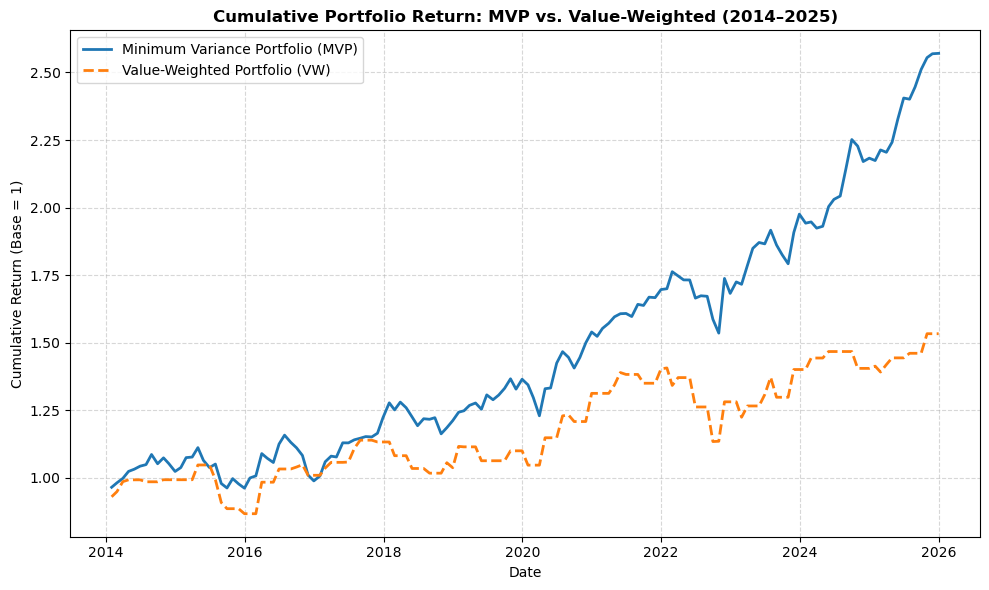

                                    Value-Weighted Portfolio (VW)  \
Annualized Average Return                                  5.830%   
Annualized Volatility                                     13.124%   
Annualized Cumulative Return (CAGR)                        3.625%   
Sharpe Ratio                                                0.314   
Minimum Monthly Return                                   -10.143%   
Maximum Monthly Return                                    13.442%   

                                    Minimum Variance Portfolio (MVP)  
Annualized Average Return                                     8.413%  
Annualized Volatility                                        10.305%  
Annualized Cumulative Return (CAGR)                           8.186%  
Sharpe Ratio                                                   0.620  
Minimum Monthly Return                                       -6.849%  
Maximum Monthly Return                                       13.176%  

Fichier SAAM_Part1

In [ ]:
# ── 1. Rendements cumulés ────────────────────────────────────────────────────
cumret_mvp = (1 + pf_ret_mvp).cumprod()
cumret_vw  = (1 + pf_vw_ret).cumprod()

# ── 2. Graphique ─────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.plot(cumret_mvp.index, cumret_mvp.values, label="Minimum Variance Portfolio (MVP)", color='tab:blue', linewidth=2)
plt.plot(cumret_vw.index,  cumret_vw.values,  label="Value-Weighted Portfolio (VW)",   color='tab:orange', linewidth=2, linestyle="--")
plt.title("Cumulative Portfolio Return: MVP vs. Value-Weighted (2014–2025)", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Cumulative Return (Base = 1)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ── 3. Rendement cumulé annualisé (CAGR) ─────────────────────────────────────
# Formule : (1 + R_total)^(1/n_années) - 1, avec n_années = T/12 = 12
T = len(pf_ret_mvp)  # 144 mois
ann_cum_ret_mvp = (cumret_mvp.iloc[-1]) ** (12 / T) - 1
ann_cum_ret_vw  = (cumret_vw.iloc[-1])  ** (12 / T) - 1

# ── 4. Tableau récapitulatif des 6 métriques ─────────────────────────────────
comparison_df = pd.DataFrame({
    "Value-Weighted Portfolio (VW)": [
        f"{ann_return_vw:.3%}",
        f"{ann_volatility_vw:.3%}",
        f"{ann_cum_ret_vw:.3%}",
        f"{ann_sharpe_vw:.3f}",
        f"{min_ret_vw:.3%}",
        f"{max_ret_vw:.3%}"
    ],
    "Minimum Variance Portfolio (MVP)": [
        f"{ann_return:.3%}",
        f"{ann_volatility:.3%}",
        f"{ann_cum_ret_mvp:.3%}",
        f"{ann_sharpe:.3f}",
        f"{min_ret:.3%}",
        f"{max_ret:.3%}"
    ]
}, index=[
    "Annualized Average Return",
    "Annualized Volatility",
    "Annualized Cumulative Return (CAGR)",
    "Sharpe Ratio",
    "Minimum Monthly Return",
    "Maximum Monthly Return"
])

print(comparison_df)

# ── 5. Export Excel ───────────────────────────────────────────────────────────
export_returns = pd.DataFrame({
    "Value-Weighted Portfolio": pf_vw_ret,
    "Minimum Variance Portfolio": pf_ret_mvp
})

with pd.ExcelWriter("SAAM_Part1_Export.xlsx") as writer:
    comparison_df.to_excel(writer, sheet_name="Metrics")
    export_returns.to_excel(writer, sheet_name="Monthly_Returns")

print("\nFichier SAAM_Part1_Export.xlsx sauvegardé.")


---
# Part II — Portfolio Allocation with Carbon Emission Reduction

## 3. Allocation with a 50% Reduction in Carbon Emissions

### 3.1 Carbon Emissions

### 3.2 Long-Only Portfolio with a Carbon Footprint Objective

### 3.3 Tracking Error Minimization

### 3.4 Comparison of Portfolios

---
## 4. Portfolio Allocation with a Net Zero Objective

### 4.1 Net Zero Portfolio

### 4.2 Comparison of Portfolios